In [136]:
# from src.evaluation.binary_class_evaluation import 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, average_precision_score, precision_recall_curve
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../../')))

In [22]:
kuzmin = pd.read_csv("../../../../input/data/kuzmin/kuzmin_no_gaps.csv")
witheld = kuzmin[kuzmin['virus_species'] != "Severe_acute_respiratory_syndrome_related_coronavirus"]

In [25]:
virus_list = witheld.virus_species.unique()
len(virus_list)

60

In [110]:
human_virus_species_set = {
    "Human_coronavirus_NL63",
    "Betacoronavirus_1",
    "Human_coronavirus_HKU1",
    "Severe_acute_respiratory_syndrome_related_coronavirus",
    "SARS_CoV_2",
    "Human_coronavirus_229E",
    "Middle_East_respiratory_syndrome_coronavirus",
}

def is_human_virus(virus_species):
    if virus_species in human_virus_species_set:
        return 1
    else: 
        return 0
    
def get_virus_species(itr):
    return virus_list[itr]

def merge_cols(row):
    positive_label = row[2]
    one = row[6]
    if not pd.isna(positive_label):
        return positive_label
    else:
        return one
    
    

In [113]:
results = pd.read_csv("kuzmin_hybrid_attention_LOOCV_2l_d1024_lr3e-4_output.csv")
results['virus_species'] = results['itr'].apply(get_virus_species)
results['target'] = results['virus_species'].apply(is_human_virus)
results['target_pred'] = results.apply(merge_cols, axis=1)

In [114]:
fpr, tpr, _ = roc_curve(results['target'], results['target_pred'])
auc = roc_auc_score(results['target'], results['target_pred'])

In [115]:
# Get average pred by species 
results_by_species = results.groupby('virus_species').agg("mean").reset_index()
display(results_by_species)
fpr_species, tpr_species, _ = roc_curve(results_by_species['target'], results_by_species['target_pred'])
auc_species = roc_auc_score(results_by_species['target'], results_by_species['target_pred'])

,virus_species,Unnamed: 0,negative_label,positive_label,itr,0,1,target,target_pred
0,229E_related_bat_coronavirus,0.0,NaN,NaN,16.0,0.283846,0.716154,0.0,0.716154
1,Alphacoronavirus_1,18.0,NaN,NaN,28.0,0.793797,0.206203,0.0,0.206203
2,Avian_coronavirus,140.5,0.659086,0.340914,0.0,NaN,NaN,0.0,0.340914
3,Bat_Coronavirus_HKU10,0.0,NaN,NaN,20.0,0.000027,0.999973,0.0,0.999973
4,Bat_coronavirus,4.5,NaN,NaN,9.0,0.696431,0.303569,0.0,0.303569
5,Bat_coronavirus_1B,0.0,NaN,NaN,3.0,0.077779,0.922221,0.0,0.922221
6,Bat_coronavirus_BM48_31/BGR/2008,0.0,NaN,NaN,45.0,0.776272,0.223728,0.0,0.223728
7,Bat_coronavirus_CDPHE15,0.5,NaN,NaN,7.0,0.902570,0.097430,0.0,0.097430
8,Bat_coronavirus_HKU10,3.0,NaN,NaN,6.0,0.520341,0.479659,0.0,0.479659
9,Beluga_Whale_coronavirus_SW1,1.0,NaN,NaN,54.0,0.644207,0.355793,0.0,0.355793


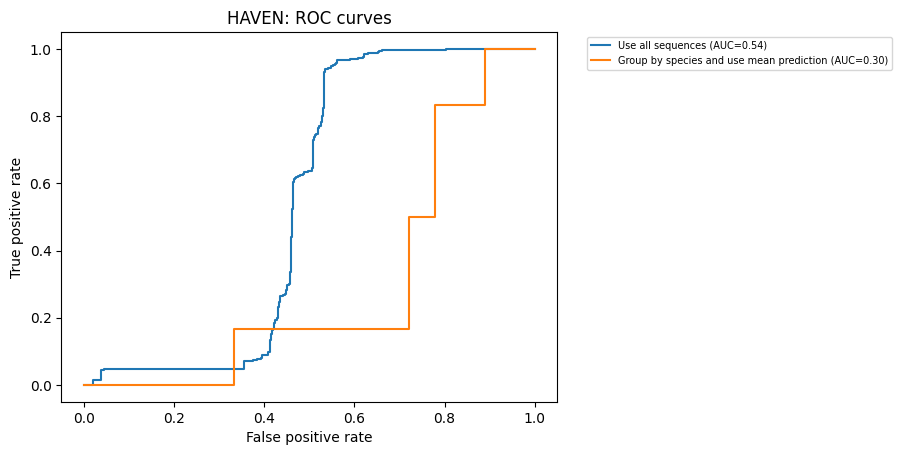

In [127]:
plt.step(fpr, tpr, where="post", label="Use all sequences (AUC=%.2f)" % (auc,))
plt.step(fpr_species,tpr_species,where="post",label="Group by species and use mean prediction (AUC=%.2f)" % (auc_species,),)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("HAVEN: ROC curves")
plt.legend(loc="upper left", fontsize=7, bbox_to_anchor=(1.05, 1))
plt.savefig('model_eval_ROC.jpg', bbox_inches='tight')

plt.show()

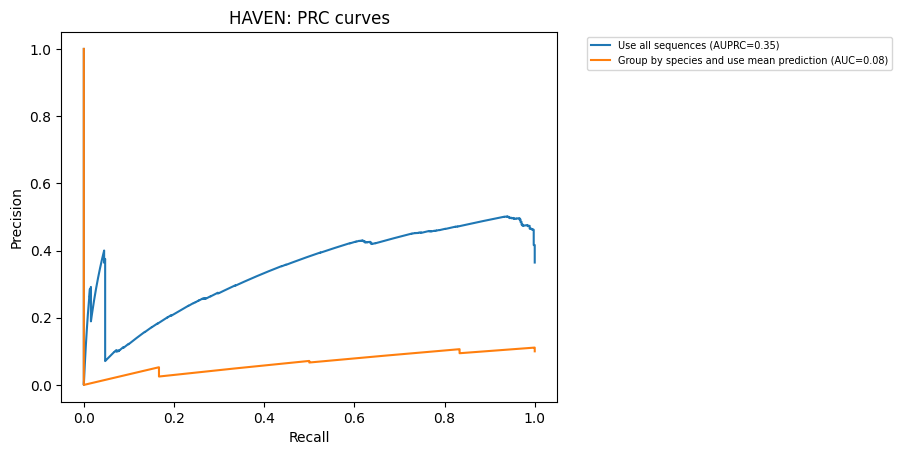

In [124]:
auprc_score = average_precision_score(y_true=results['target'].values, y_score=results['target_pred'].values, pos_label=1)
precision, recall, _ = precision_recall_curve(y_true=results['target'].values, probas_pred=results['target_pred'].values, pos_label=1)

auprc_score_species = average_precision_score(y_true=results_by_species['target'].values, y_score=results_by_species['target_pred'].values, pos_label=1)
precision_species, recall_species, _ = precision_recall_curve(y_true=results_by_species['target'].values, probas_pred=results_by_species['target_pred'].values, pos_label=1)


plt.plot(recall, precision, label="Use all sequences (AUPRC=%.2f)" % (auprc_score,))
plt.plot(recall_species,precision_species,label="Group by species and use mean prediction (AUC=%.2f)" % (auprc_score_species,),)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("HAVEN: PRC curves")
plt.legend(loc="upper left", fontsize=7, bbox_to_anchor=(1.05, 1))
plt.savefig('model_eval_PRC.jpg')

plt.show()

# Test Label Situation

In [91]:
test_df = results[results['itr'] == 40]
test_df = test_df[['0', '1', 'y_true']]
test_df

,0,1,y_true
853,0.972849,0.027151,0
854,0.971957,0.028043,0
855,0.968632,0.031368,0
856,0.970994,0.029006,0
857,0.972180,0.027820,0
...,...,...,...
1116,0.970012,0.029988,0
1117,0.972724,0.027276,0
1118,0.968261,0.031739,0
1119,0.971576,0.028424,0


In [138]:
from utils import utils, dataset_utils

df = kuzmin[['id_num', 'sequence', 'classification', 'virus_species']]
label_settings = {'label_col': "classification",
    'exclude_labels': [ "nan" ],
    'label_groupings': {
      "positive_label": [ "human" ],
      "negative_label": [ "Not human" ]}}


df, index_label_map = utils.transform_labels(kuzmin, label_settings,
                                                           classification_type='binary')

training_set = df[df['virus_species'] != 'Betacoronavirus_1']
train_df, val_df = dataset_utils.split_dataset_stratified(training_set, 2025,
                                                                       .8, stratify_col='classification')

train_df



/opt/anaconda3/envs/haven/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Grouping labels using config : {'positive_label': ['human'], 'negative_label': ['Not human']}
[0 1]
label_idx_map={0: 0, 1: 1}
idx_label_map={0: 0, 1: 1}
Splitting dataset with seed=2025, train_proportion=0.8, stratify_col=classification
Size of train_dataset = (843, 8)
Size of test_dataset = (211, 8)


,Unnamed: 0,strain_name,id_num,host_species,virus_species,sequence,target,classification
48,48,BtKYNL63_9a,APD51475,Bat,NL63-related_bat_coronavirus,MKLFTFMCLLSLGLAQKTCFSGDYRELKLGLPPSVNATVTGYLPIN...,0,0
120,120,camel/Jeddah/D33_a_/2014,ALA50158,Camel,Human_coronavirus_229E,MFVLVAYALLHIAGCQTINVLNTSHSVCNGCVGYSENVFAVESGGY...,1,1
210,210,ck/CH/LDL/091022,AFQ94213,Chicken,Avian_coronavirus,MLGKSLFLVTILCALCSANLFDSANNYVYYYQSAFRPPNGWHLQGG...,0,0
920,920,AJ1102_F12_,QGZ28404,Swine,Porcine_epidemic_diarrhea_virus,MKSLTYFWLFLPVLSTLSLPQDVTRCSANTNFRRFFSKFNVQAPAV...,0,0
651,651,016,QDP16195,Human,Middle_East_respiratory_syndrome_coronavirus,MIHSVFLLMFLLTPTESYVDVGPDSLKSACIEVDIQQTFFDKTWPR...,1,1
...,...,...,...,...,...,...,...,...
633,633,Hu/Riyadh_KSA_9852/2017,AVK87439,Human,Middle_East_respiratory_syndrome_coronavirus,MIHSVFLLMFLLTPTESYVDVGPDSVKSACIEVDIQQTFFDKTWPR...,1,1
21,21,LLJ_2004,AAT52330,Bat,Severe_acute_respiratory_syndrome_related_coro...,MFIFLLFLTLTSGSDLDRCTTFDDVQAPNYTQHTSSMRGVYYPDEI...,1,1
861,861,CH/SCZY44/2017,AZL47204,Swine,Porcine_epidemic_diarrhea_virus,MKSLTHFWLFLPVLSTFSLPQDVTRCQLTTNFRRFFSKFNVQAPAV...,0,0
145,145,camel/UAE_B26_2015,ASU90186,Camel,Middle_East_respiratory_syndrome_coronavirus,MIHSVFLLMFLLTPTESYVDVGPDSVKPACIEVDIQQTFFDKTWPR...,1,1


In [142]:
len(val_df[val_df['classification'] == 1])

56

In [143]:
56 / 211

0.26540284360189575

In [128]:
df

,Unnamed: 0,strain_name,id_num,host_species,virus_species,sequence,target,classification
0,0,TW2575/98,ABG36787,Chicken,Avian_coronavirus,MLVKSLFLATLLFALSSATLYDNDTYVYYYQSAFRPSNGWHLHGGA...,0,0
1,1,N25,ABD75545,Human,Human_coronavirus_HKU1,MFLIIFILPTTLAVIGDFNCTNSFINDYNKTIPRISEDVVDVSLGL...,1,1
2,2,Quebec,AAL40400,Cattle,Betacoronavirus_1,MFLILLISLPMAFAVIGDLKCTTVSINDVDTGAPSISTDIVDVTNG...,1,1
3,3,TCoV_540,ABW75125,Turkey,Avian_coronavirus,MVAPLCCLTIILSLACNVSSIPTICNNATVGSGECVPCTDIPEYAH...,0,0
4,4,BCoV_LUN,AAL57308,Cattle,Betacoronavirus_1,MFLILLISLPTAFAVIGDLKCTTVSINDVDTGVPSISTDTVDVTKG...,1,1
...,...,...,...,...,...,...,...,...
1233,1233,JSX2014/ATT,AZN28588,Swine,Porcine_epidemic_diarrhea_virus,MKSLTYFWLFLPVLSTLSLPQDVTRCSANTNFRRFFSKFNVQAPAV...,0,0
1234,1234,CZ01,AWH65877,Bat,Tylonycteris_bat_coronavirus_HKU4,MTLLMCLLMSLLIFVRGCESQFVDMSPASNNSECLDSQVDAAAFSK...,0,0
1235,1235,SZ140324,AWH65899,Bat,Tylonycteris_bat_coronavirus_HKU4,MTLLMCLLMSLLIFVRGCDSQFVDMSPASNTSECLESQVDAAAFSK...,0,0
1236,1236,CZ07,AWH65888,Bat,Tylonycteris_bat_coronavirus_HKU4,MTRLMCLLMSLLIFVRGCDSQFVDMSPASNNSECLDSQVDAAAFSK...,0,0


In [87]:
index_label_map

{0: 'negative_label', 1: 'positive_label'}

In [103]:
test_df = results[(results['itr'] == 40) | (results['itr'] == 8)]
test_df = test_df[['0', '1', 'y_true']]
test_df.rename(columns=index_label_map, inplace=True)
# test_df["y_true"] = test_df["y_true"].map(index_label_map)

In [104]:
test_df

,0,1,y_true
504,0.849892,0.150108,1
505,0.850776,0.149224,1
506,0.858197,0.141803,1
507,0.851519,0.148481,1
508,0.839815,0.160185,1
...,...,...,...
1116,0.970012,0.029988,0
1117,0.972724,0.027276,0
1118,0.968261,0.031739,0
1119,0.971576,0.028424,0
